In [1]:
import numpy as np
import json
import wget
from bs4 import BeautifulSoup
import tarfile
from astropy.table import Table
import os

In [2]:
#base_url = 'https://s3.amazonaws.com/grizli-v2/JwstMosaics/v6/index.html'
base_url = 'https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/index.html'
output_directory = '/Users/marchuertascompany/Documents/data/astropile/ceers/'  # Update this path as needed
field_identifier = 'ceers'

# make sure the output directory exists
try:
    os.chdir(output_directory)
    os.chdir('..')
except:
    print('output directory not found, made the dir.')
    os.mkdir(output_directory)


# Download the index.html file
file = wget.download(base_url)

# Read the content of the file
with open(file, "r") as f:
    file_content = f.read()

# Parse the HTML content
soup = BeautifulSoup(file_content, 'html.parser')

jwstfiles = []
for temp in soup.find_all('a'):
    if (field_identifier in temp['href']) and ('_sci' in temp['href']):
        jwstfiles.append(temp['href'])

# Print and download files
for url in jwstfiles:
    # Extract the filename from the URL
    filename = url.split('/')[-1]
    
    # Determine the filter from the filename
    temp = filename.split('_')[0].split('-')
    if temp[-1] != 'clear':
        filter_name = temp[-1]
    else:
        filter_name = temp[-2]

    # Print filter info and URL
    print('\nfilter: ', filter_name)
    print('url: ', url)

    # Construct the full local filepath
    full_local_path = os.path.join(output_directory, filename)

    # Download the file to the specified output directory
    wget.download(url, out=full_local_path)

# for the photometry table
for temp in soup.find_all('a'):
    if (field_identifier in temp['href']) & ('photoz' in temp['href']):
        print(temp['href'])
        photoz_url = temp['href']

# download the photoz file
filename = photoz_url.split('/')[-1]
full_local_path = os.path.join(output_directory, filename)
file = wget.download(photoz_url, out=output_directory)

# unzip the file
tar = tarfile.open(file)
tar.extractall(path=output_directory)
tar.close()

# read it in as a table
fnames = os.listdir(output_directory)
for fname in fnames:
    if 'eazypy.zout' in fname:
        phot_table = Table.read(output_directory + fname)
phot_table


filter:  f1000w
url:  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-f1000w_drz_sci.fits.gz

filter:  f115w
url:  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-f115w-clear_drc_sci.fits.gz

filter:  f1280w
url:  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-f1280w_drz_sci.fits.gz

filter:  f1500w
url:  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-f1500w_drz_sci.fits.gz

filter:  f150w
url:  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-f150w-clear_drc_sci.fits.gz

filter:  f1800w
url:  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-f1800w_drz_sci.fits.gz

filter:  f182m
url:  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-f182m-clear_drc_sci.fits.gz

filter:  f200w
url:  https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-f200w-clear_drc_sci.fits.gz

filter:  f2100w
url:  https://s

KeyboardInterrupt: 

In [3]:
# for the photometry table
for temp in soup.find_all('a'):
    if (field_identifier in temp['href']) & ('photoz' in temp['href']):
        print(temp['href'])
        photoz_url = temp['href']

# download the photoz file
filename = photoz_url.split('/')[-1]
full_local_path = os.path.join(output_directory, filename)
file = wget.download(photoz_url, out=output_directory)

# unzip the file
tar = tarfile.open(file)
tar.extractall(path=output_directory)
tar.close()

# read it in as a table
fnames = os.listdir(output_directory)
for fname in fnames:
    if 'eazypy.zout' in fname:
        phot_table = Table.read(output_directory + fname)
phot_table


https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.0-fix.photoz.tar.gz
https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/ceers-full-grizli-v7.2-fix.photoz.tar.gz


id,ra,dec,z_spec,nusefilt,z_ml,z_ml_chi2,z_ml_risk,lc_min,lc_max,z_phot,z_phot_chi2,z_phot_risk,z_min_risk,min_risk,z_raw_chi2,raw_chi2,z025,z160,z500,z840,z975,restU,restU_err,restB,restB_err,restV,restV_err,restJ,restJ_err,dL,mass,sfr,Lv,LIR,energy_abs,Lu,Lj,L1400,L2800,LHa,LOIII,LHb,LOII,MLv,Av,lwAgeV,mass_p,sfr_p,Lv_p,LIR_p,energy_abs_p,Lu_p,Lj_p,L1400_p,L2800_p,LHa_p,LOIII_p,LHb_p,LOII_p,Av_p,ssfr_p,rest120,rest120_err,rest121,rest121_err,rest156,rest156_err,rest157,rest157_err,rest158,rest158_err,rest159,rest159_err,rest160,rest160_err,rest414,rest414_err,rest415,rest415_err,rest416,rest416_err
,deg,deg,,,,,,,,,,,,,,,,,,,,,,,,,,,,Mpc,solMass,solMass / yr,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solMass / solLum,,Gyr,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int32,float64,float64,float64,int64,float32,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
1,215.2138016303901,52.97431301112107,-1.0,0,-1.0,-1.0,-1.0,43188281021088.9,0.0,-1.0,-1.0,-1.0,0.01,0.0,0.01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0e+00,-9.00e+29,-900000000000000046043660025856.000,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-900000000000000046043660025856.00,-900000000000000046043660025856.00,-900000000000000046043660025856.00,-9.00e+29 .. -9.00e+29,-900000000000000046043660025856.000 .. -900000000000000046043660025856.000,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-900000000000000046043660025856.00 .. -900000000000000046043660025856.00,-9.00e+29 .. -9.00e+29,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,215.18642021131978,52.95481340768697,-1.0,0,-1.0,-1.0,-1.0,43188281021088.9,0.0,-1.0,-1.0,-1.0,0.01,0.0,0.01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0e+00,-9.00e+29,-900000000000000046043660025856.000,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-900000000000000046043660025856.00,-900000000000000046043660025856.00,-900000000000000046043660025856.00,-9.00e+29 .. -9.00e+29,-900000000000000046043660025856.000 .. -900000000000000046043660025856.000,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-900000000000000046043660025856.00 .. -900000000000000046043660025856.00,-9.00e+29 .. -9.00e+29,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,215.1744071977536,52.94625083256462,-1.0,0,-1.0,-1.0,-1.0,43188281021088.9,0.0,-1.0,-1.0,-1.0,0.01,0.0,0.01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0e+00,-9.00e+29,-900000000000000046043660025856.000,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-900000000000000046043660025856.00,-900000000000000046043660025

In [7]:
phot_table['ra'][0]

215.2138016303901

In [21]:
import os
import glob
import pickle
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata.utils import Cutout2D
from astropy.coordinates import SkyCoord
import pickle


filter_list = ['f200w'] # add filters here
image_size = 96

# Set the directory path
output_directory = '/Users/marchuertascompany/Documents/data/astropile/ceers/'
directory_path = output_directory

# Pattern to match files starting with 'ceers' and ending with 'fits.gz'
pattern = 'ceers*fits.gz'

# Construct the full path pattern
full_path_pattern = os.path.join(directory_path, pattern)

# List all matching files
matching_files = glob.glob(full_path_pattern)

for f in filter_list:

    # Loop over the matching files
    for file_path in matching_files:
        print(file_path)  # Print the file path or do something with the file
        if f in file_path:
            im = fits.open(file_path)
            sci=im['PRIMARY'].data
            wcs = WCS((im['PRIMARY'].header))



            ravec=[]
            decvec=[]
            JWST_stamps=[]
            idvec=[]
            for idn, ra,dec in zip(phot_table['id'], phot_table['ra'], phot_table['dec']):
                try:
                    #full = 'nircam_'+str(field)+'_'+str(idn)
                    position = SkyCoord(ra,dec,unit="deg")
                    #print(ra,dec)
                    stamp = Cutout2D(sci,position,image_size,wcs=wcs)
                    
                    if np.max(stamp.data)<=0 or np.count_nonzero(stamp.data==0)>10:
                        continue
                    
                    #transform = AsinhStretch() + interval
                    #norm = transform(stamp.data)  
                    norm = stamp
                    #pdb.set_trace()
                    #stamp_name = data_path+"NirCam/CANDELS_stamps/v005/f200fullres/CANDELS-CEERS"+str(idn)+"_f200w_v005.fits"
                    JWST_stamps.append(norm)
                    idvec.append(idn)
                    
                    ravec.append(ra)
                    decvec.append(dec)  
                    #if (fsph>0.66 and fdk<0.66 and firr<0.1):
                    #    label.append(1)
                    #else:
                    #    label.append(0)
                
                    
                except:
                    continue
           

            # Define the filename for the pickle file
            pickle_filename = output_directory+'/jwst_'+field_identifier+'_'+f+'_forastropile.pkl'  # Update the path as needed

            # Open a file for writing the pickle data
            with open(pickle_filename, 'wb') as pickle_file:
                # Create a dictionary to store your lists
                data_to_store = {
                    'JWST_stamps': JWST_stamps,
                    'idvec': idvec,
                    'ravec': ravec,
                    'decvec': decvec
                }
                # Use pickle.dump() to store the data in the file
                pickle.dump(data_to_store, pickle_file)

            print(f'Data stored in {pickle_filename}')


/Users/marchuertascompany/Documents/data/astropile/ceers/ceers-full-grizli-v7.0-f182m-clear_drc_sci.fits.gz
/Users/marchuertascompany/Documents/data/astropile/ceers/ceers-full-grizli-v7.0-f200w-clear_drc_sci.fits.gz
Data stored in /Users/marchuertascompany/Documents/data/astropile/ceers//jwst_ceers_f200w_forastropile.pkl
/Users/marchuertascompany/Documents/data/astropile/ceers/ceers-full-grizli-v7.0-f2100w_drz_sci.fits.gz


TypeError: 'in <string>' requires string as left operand, not _io.BufferedWriter

In [19]:
print(len(JWST_stamps))

65885


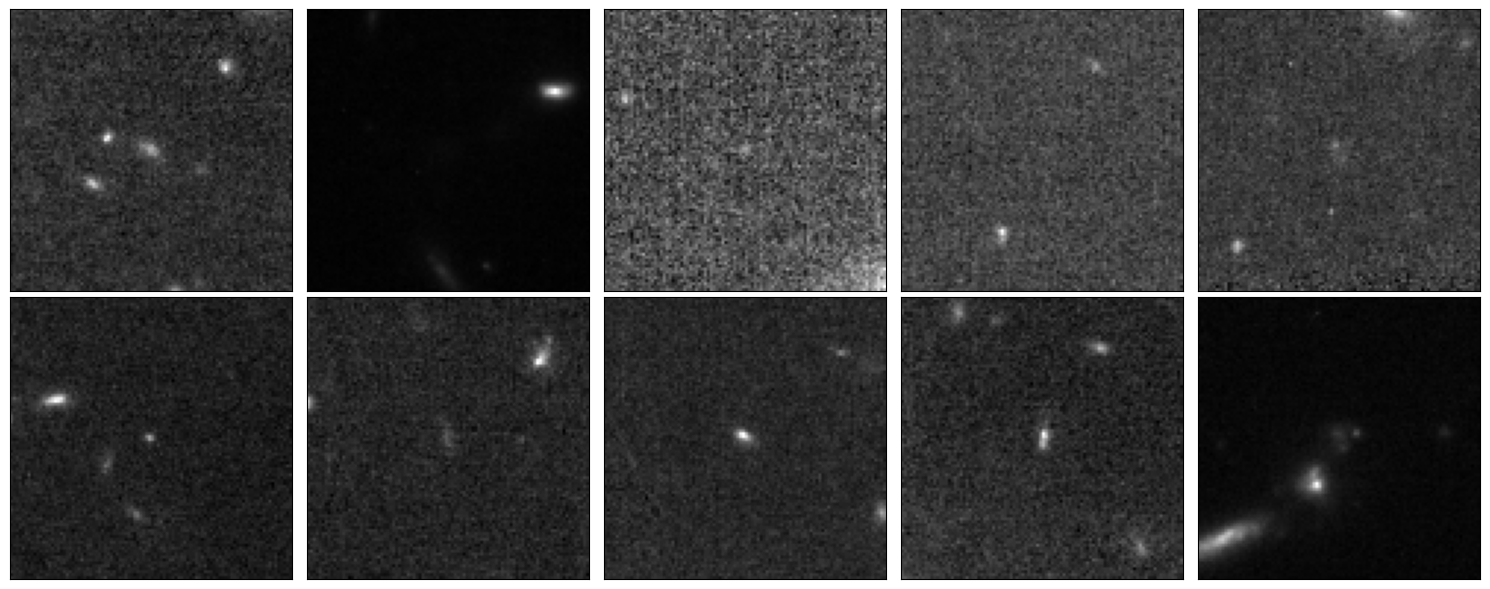

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Check if there are at least 10 stamps; if not, use the total number of stamps
num_stamps = min(10, len(JWST_stamps))

# Select 10 random stamps if there are enough, otherwise select all
selected_stamps = np.random.choice(JWST_stamps, size=num_stamps, replace=False)

# Create a figure and axes with 2 rows and 5 columns
fig, axs = plt.subplots(2, 5, figsize=(15, 6))

# Flatten the array of axes to make indexing easier
axs_flat = axs.flatten()

# Loop through the selected stamps and the flattened axes
for stamp, ax in zip(selected_stamps, axs_flat):
    # Display the stamp on the current axis
    ax.imshow(stamp.data, origin='lower', cmap='gray')
    # Remove the axis ticks
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused axes if there are less than 10 stamps
for i in range(num_stamps, 10):
    axs_flat[i].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [9]:
print(im.info())

Filename: /Users/marchuertascompany/Documents/data/astropile/ceers/ceers-full-grizli-v7.0-f200w-clear_drc_sci.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     640   (36864, 12288)   float32   
None
